# Data Preprocessing & Normalization Pipeline

This notebook handles all data cleaning, feature engineering, encoding, and scaling before model training.

Steps:
1. Load raw data
2. Handle missing values
3. Generate derived features
4. One-hot encode categoricals
5. Scale numerical features
6. Split into plumbing / electrical / structural subsets
7. Save everything

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Imports done')

Imports done


## 1. Load and Explore Data

In [14]:
df = pd.read_csv('../data/TS-PS3.csv')
print(f'Shape: {df.shape}')
print(f'Categories: {df["category"].unique()}')
print(f'\nCategory counts:')
print(df['category'].value_counts())
df.head()

Shape: (50000, 28)
Categories: ['plumbing' 'structural' 'electrical']

Category counts:
category
structural    16776
plumbing      16712
electrical    16512
Name: count, dtype: int64


,school_id,district,block,school_type,girls_school,num_students,building_age,material_type,weather_zone,category,...,roof_leak_flag,photo_uploaded,days_to_failure,failure_within_30_days,failure_within_60_days,priority_score,repair_done,days_since_repair,contractor_delay_days,sla_breach
0,2126,Kutch,Block A,Primary,0,662,2,RCC,Dry,plumbing,...,1,1,-9.954486,1,1,56.62,0,NaN,6,0
1,2459,Surat,Block B,Primary,0,1021,50,Temporary,Heavy Rain,structural,...,1,1,-2.702698,1,1,60.21,0,NaN,7,0
2,1860,Ahmedabad,Block A,Primary,0,196,35,Brick,Coastal,structural,...,0,1,46.698777,0,1,1.96,0,NaN,26,1
3,2294,Ahmedabad,Block A,Secondary,0,939,55,Temporary,Heavy Rain,electrical,...,0,0,42.451534,0,1,9.39,0,NaN,25,1
4,2130,Dahod,Block B,Secondary,0,1096,19,RCC,Dry,structural,...,1,0,-15.526540,1,1,60.96,0,NaN,8,1


In [15]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values:
school_id                        0
district                         0
block                            0
school_type                      0
girls_school                     0
num_students                     0
building_age                     0
material_type                    0
weather_zone                     0
category                         0
week_number                      0
condition_score                  0
issue_flag                       0
water_leak                       0
wiring_exposed                   0
crack_width_mm                   0
toilet_functional_ratio          0
power_outage_hours_weekly        0
roof_leak_flag                   0
photo_uploaded                   0
days_to_failure                  0
failure_within_30_days           0
failure_within_60_days           0
priority_score                   0
repair_done                      0
days_since_repair            40029
contractor_delay_days            0
sla_breach                       0
dtyp

In [16]:
df.describe().round(2)

,school_id,girls_school,num_students,building_age,week_number,condition_score,issue_flag,water_leak,wiring_exposed,crack_width_mm,...,roof_leak_flag,photo_uploaded,days_to_failure,failure_within_30_days,failure_within_60_days,priority_score,repair_done,days_since_repair,contractor_delay_days,sla_breach
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.0,50000.0,50000.00,...,50000.0,50000.00,50000.00,50000.00,50000.00,50000.00,50000.0,9971.00,50000.00,50000.00
mean,2006.37,0.30,776.51,29.93,6.48,2.99,0.40,0.5,0.5,10.03,...,0.5,0.70,39.82,0.38,0.74,32.72,0.2,29.47,14.45,0.73
std,575.51,0.46,418.86,17.00,3.45,1.41,0.49,0.5,0.5,5.75,...,0.5,0.46,29.71,0.49,0.44,26.26,0.4,17.42,8.64,0.44
min,1000.00,0.00,50.00,1.00,1.00,1.00,0.00,0.0,0.0,0.00,...,0.0,0.00,-68.30,0.00,0.00,0.50,0.0,0.00,0.00,0.00
25%,1513.00,0.00,412.00,15.00,3.00,2.00,0.00,0.0,0.0,5.10,...,0.0,0.00,18.62,0.00,0.00,8.88,0.0,14.00,7.00,0.00
50%,2007.00,0.00,778.00,30.00,6.00,3.00,0.00,0.0,1.0,10.01,...,0.0,1.00,39.88,0.00,1.00,25.61,0.0,29.00,14.00,1.00
75%,2506.00,1.00,1140.00,45.00,9.00,4.00,1.00,1.0,1.0,15.01,...,1.0,1.00,60.89,1.00,1.00,57.62,0.0,45.00,22.00,1.00
max,2999.00,1.00,1499.00,59.00,12.00,5.00,1.00,1.0,1.0,20.00,...,1.0,1.00,153.70,1.00,1.00,84.99,1.0,59.00,29.00,1.00


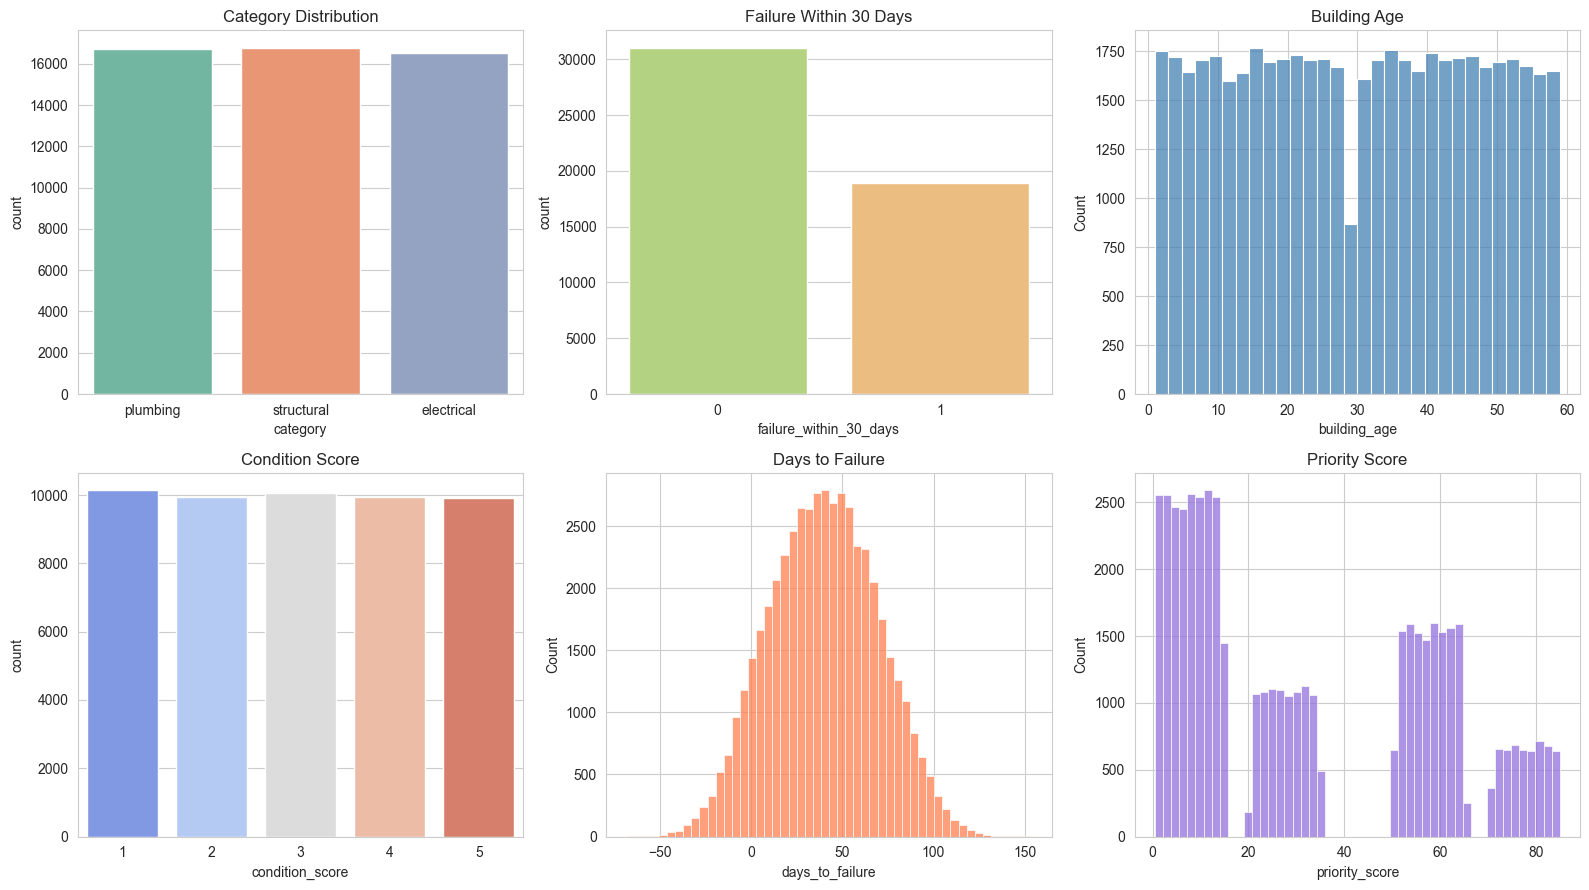

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.countplot(data=df, x='category', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Category Distribution')

sns.countplot(data=df, x='failure_within_30_days', ax=axes[0,1], palette='RdYlGn_r')
axes[0,1].set_title('Failure Within 30 Days')

sns.histplot(df['building_age'], bins=30, ax=axes[0,2], color='steelblue')
axes[0,2].set_title('Building Age')

sns.countplot(data=df, x='condition_score', ax=axes[1,0], palette='coolwarm')
axes[1,0].set_title('Condition Score')

sns.histplot(df['days_to_failure'], bins=50, ax=axes[1,1], color='coral')
axes[1,1].set_title('Days to Failure')

sns.histplot(df['priority_score'], bins=50, ax=axes[1,2], color='mediumpurple')
axes[1,2].set_title('Priority Score')

plt.tight_layout()
plt.show()

## 2. Handle Missing Values

- Numerical columns filled with median
- Categorical columns filled with mode

In [18]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Missing after imputation: {df.isnull().sum().sum()}')

Missing after imputation: 0


## 3. Feature Engineering

Derived features:
- `students_per_toilet` — sanitation load
- `students_per_classroom` — density
- `weeks_since_last_repair` — maintenance gap
- `urgency_score` — 60 minus days to failure
- `deterioration_rate` — how fast condition is dropping
- `condition_trend` — rolling change in condition
- `flood_prone_area` — binary flag
- `crack_growth_rate` — crack speed
- `condition_category` — Low/Medium/High
- `structural_severity` — Safe/Warning/Danger
- `priority_label` — Low/Medium/High/Critical

In [19]:
# students per toilet
df['students_per_toilet'] = df['num_students'] / (df['toilet_functional_ratio'] * 10 + 1)

# students per classroom (approx 10 classrooms per school)
df['students_per_classroom'] = df['num_students'] / 10

# weeks since last repair
df['days_since_repair'] = df['days_since_repair'].fillna(0)
df['weeks_since_last_repair'] = df['days_since_repair'] / 7

# urgency score
df['urgency_score'] = 60 - df['days_to_failure']

# deterioration rate
df['deterioration_rate'] = (5 - df['condition_score']) / (df['building_age'] + 1)

# condition trend (rolling diff grouped by school+category)
df = df.sort_values(['school_id', 'category', 'week_number'])
df['condition_trend'] = df.groupby(['school_id', 'category'])['condition_score'].diff().fillna(0)
df['condition_trend'] = df.groupby(['school_id', 'category'])['condition_trend'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)

# flood prone area
df['flood_prone_area'] = df['weather_zone'].isin(['Heavy Rain', 'Coastal']).astype(int)

# crack growth rate
df['crack_growth_rate'] = df['crack_width_mm'] / (df['building_age'] + 1)

# condition category
df['condition_category'] = pd.cut(df['condition_score'], bins=[0, 2, 3, 5],
                                   labels=['Low', 'Medium', 'High'], include_lowest=True)

# structural severity target
def get_severity(row):
    if row['condition_score'] >= 4 and row['days_to_failure'] > 60:
        return 'Safe'
    elif row['condition_score'] <= 2 and row['days_to_failure'] < 30:
        return 'Danger'
    return 'Warning'

df['structural_severity'] = df.apply(get_severity, axis=1)

# priority label
df['priority_label'] = pd.cut(df['priority_score'], bins=[-1, 25, 50, 75, 200],
                               labels=['Low', 'Medium', 'High', 'Critical'])

print(f'Shape after feature engineering: {df.shape}')
print('New columns added successfully')

Shape after feature engineering: (50000, 39)
New columns added successfully


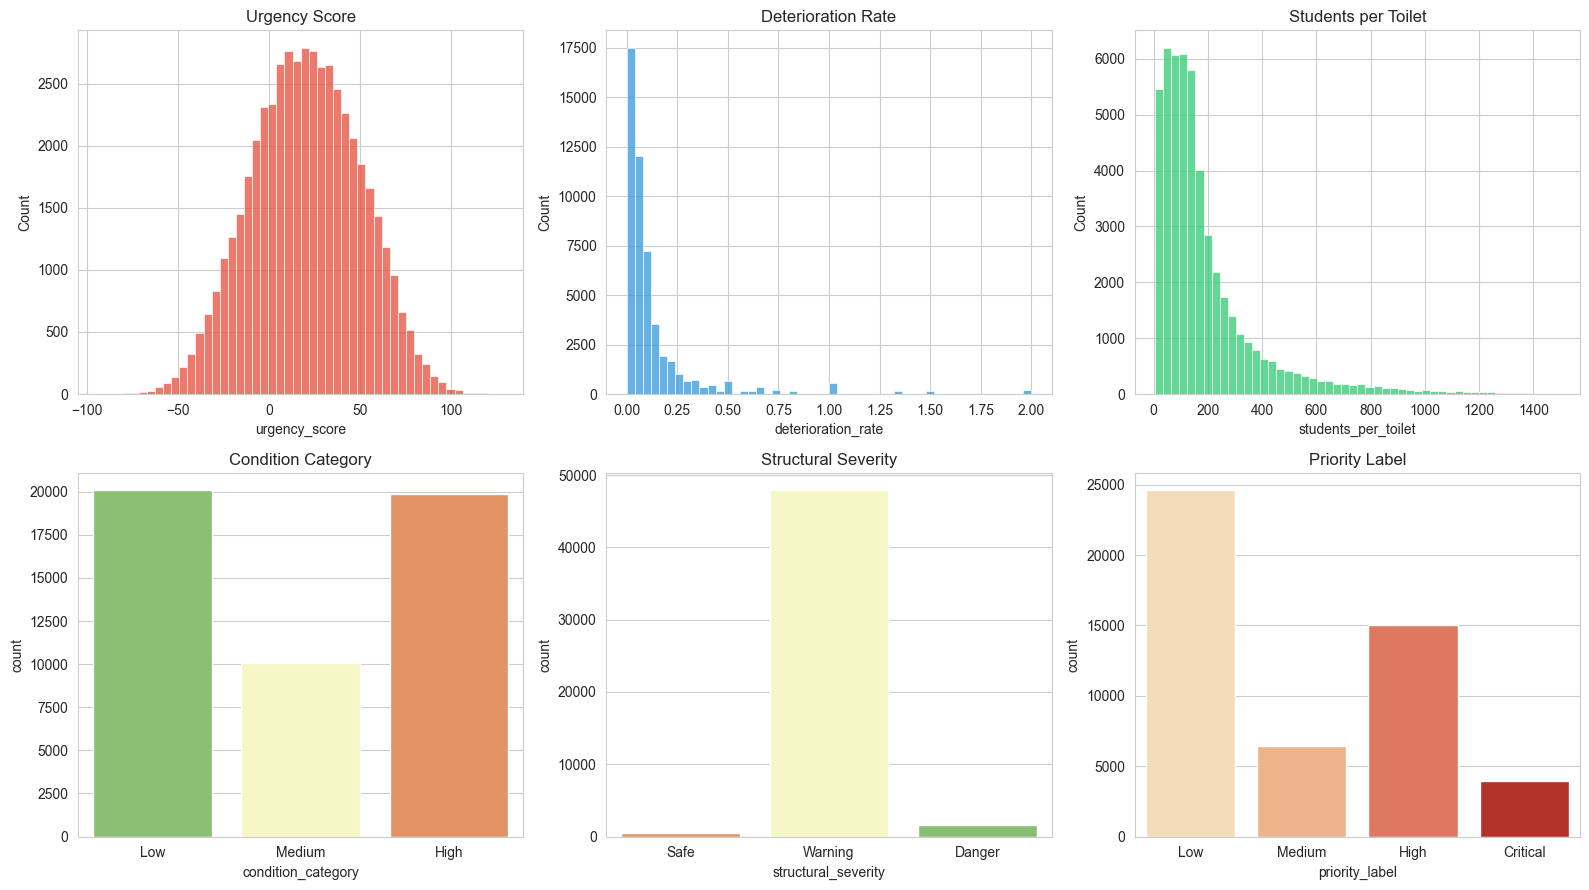

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df['urgency_score'], bins=50, ax=axes[0,0], color='#e74c3c')
axes[0,0].set_title('Urgency Score')

sns.histplot(df['deterioration_rate'], bins=50, ax=axes[0,1], color='#3498db')
axes[0,1].set_title('Deterioration Rate')

sns.histplot(df['students_per_toilet'], bins=50, ax=axes[0,2], color='#2ecc71')
axes[0,2].set_title('Students per Toilet')

sns.countplot(data=df, x='condition_category', order=['Low','Medium','High'],
              ax=axes[1,0], palette='RdYlGn_r')
axes[1,0].set_title('Condition Category')

sns.countplot(data=df, x='structural_severity', order=['Safe','Warning','Danger'],
              ax=axes[1,1], palette='RdYlGn')
axes[1,1].set_title('Structural Severity')

sns.countplot(data=df, x='priority_label', order=['Low','Medium','High','Critical'],
              ax=axes[1,2], palette='OrRd')
axes[1,2].set_title('Priority Label')

plt.tight_layout()
plt.show()

## 4. One-Hot Encode Categoricals

In [21]:
ohe_columns = ['material_type', 'weather_zone', 'condition_category', 'school_type']
df_encoded = pd.get_dummies(df, columns=ohe_columns, drop_first=False)

new_cols = [c for c in df_encoded.columns if any(c.startswith(p + '_') for p in ohe_columns)]
print(f'After encoding: {df_encoded.shape}')
print(f'One-hot columns: {new_cols}')

After encoding: (50000, 48)
One-hot columns: ['material_type_Brick', 'material_type_Mixed', 'material_type_RCC', 'material_type_Temporary', 'weather_zone_Coastal', 'weather_zone_Dry', 'weather_zone_Heavy Rain', 'weather_zone_Tribal', 'condition_category_Low', 'condition_category_Medium', 'condition_category_High', 'school_type_Primary', 'school_type_Secondary']


## 5. Scale Numerical Features

In [22]:
scale_columns = [
    'building_age', 'students_per_toilet', 'weeks_since_last_repair',
    'condition_score', 'crack_width_mm', 'deterioration_rate',
    'urgency_score', 'students_per_classroom', 'condition_trend',
    'crack_growth_rate', 'num_students', 'toilet_functional_ratio',
    'power_outage_hours_weekly', 'days_to_failure'
]

scaler = StandardScaler()
df_encoded[scale_columns] = scaler.fit_transform(df_encoded[scale_columns])

os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/standard_scaler.pkl')
joblib.dump(scale_columns, '../models/scale_columns.pkl')

print(f'Scaled {len(scale_columns)} columns')
print('Scaler saved')

Scaled 14 columns
Scaler saved


## 6. Split by Category and Save

In [23]:
df_plumbing = df_encoded[df_encoded['category'] == 'plumbing'].copy()
df_electrical = df_encoded[df_encoded['category'] == 'electrical'].copy()
df_structural = df_encoded[df_encoded['category'] == 'structural'].copy()

print(f'Plumbing:    {df_plumbing.shape[0]} rows')
print(f'Electrical:  {df_electrical.shape[0]} rows')
print(f'Structural:  {df_structural.shape[0]} rows')

Plumbing:    16712 rows
Electrical:  16512 rows
Structural:  16776 rows


In [24]:
os.makedirs('../data/preprocessed', exist_ok=True)

df_plumbing.to_csv('../data/preprocessed/plumbing_data.csv', index=False)
df_electrical.to_csv('../data/preprocessed/electrical_data.csv', index=False)
df_structural.to_csv('../data/preprocessed/structural_data.csv', index=False)
df_encoded.to_csv('../data/preprocessed/full_preprocessed.csv', index=False)

print('All preprocessed files saved to data/preprocessed/')

All preprocessed files saved to data/preprocessed/
